# From DeepWalk to node2vec to GNNs
### Session 08 · Graphs — companion demo `d3`

In **demo d1** you built DeepWalk from scratch: uniform random walks → skip-gram → node
vectors, and watched a synthetic graph's communities fall out of the geometry. This
notebook picks up exactly there and pushes on three questions:

1. **node2vec** — what if the random walk is *not* uniform? Two knobs, `p` and `q`,
   let us steer it. *(Acts 1–2)*
2. **Link prediction** — node vectors are not just pretty pictures; they predict edges
   that are not there yet. *(Act 3)*
3. **Graph neural networks** — a shallow embedding is a lookup table with real limits.
   The GCN fixes them. *(Act 4)*

Everything runs on one graph you can hold in your head: **Zachary's Karate Club** — 34
members of a 1970s university karate club that split into two factions after a feud
between the instructor ("Mr. Hi") and the club president ("Officer").

> **Run it (uv):** `uv run --with-requirements requirements.txt --with jupyterlab jupyter lab`
> — see `README.md`.

In [1]:
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys; print(sys.executable)

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score, roc_curve, auc

import ipywidgets as widgets
from ipywidgets import interact

%matplotlib inline
np.random.seed(0)
torch.manual_seed(0)
print("torch", torch.__version__, "· networkx", nx.__version__)

/home/diego/Documents/uni/kddp/labs/.venv/bin/python
torch 2.12.0+cu130 · networkx 3.6.1


## Act 0 · Meet the graph

Wayne Zachary recorded who-interacted-with-whom in the club, *and then* it split. That
split is the ground truth we keep testing our methods against — but the embedding methods
themselves never get to see it. They only see the wiring.

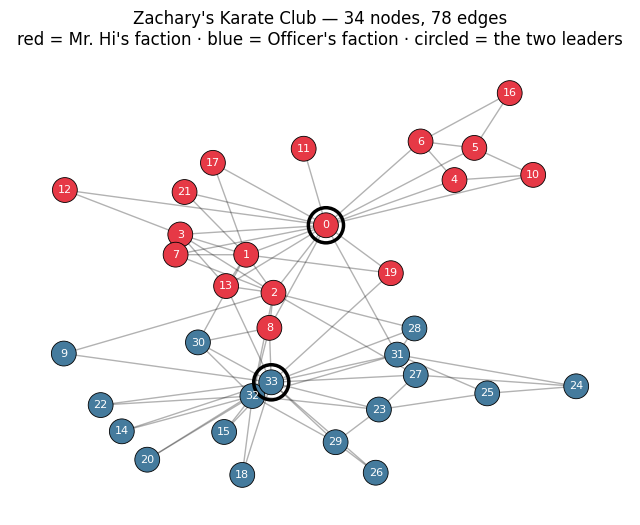

highest-degree nodes (node, degree): [(33, 17), (0, 16), (32, 12), (2, 10), (1, 9)]


In [2]:
G = nx.karate_club_graph()
N = G.number_of_nodes()

# ground-truth faction of each node (we hide this from every embedding method)
clubs = [G.nodes[i]["club"] for i in G.nodes()]
y_true = np.array([0 if c == "Mr. Hi" else 1 for c in clubs])
FACTION_COLORS = np.array(["#e63946", "#457b9d"])      # red = Mr. Hi, blue = Officer
node_color = list(FACTION_COLORS[y_true])

# one layout, reused everywhere so every picture is "the same graph"
pos = nx.spring_layout(G, seed=42, k=0.35, iterations=120)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1.0)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color, node_size=320,
                       edgecolors="black", linewidths=0.6)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")
# circle the two leaders
nx.draw_networkx_nodes(G, pos, nodelist=[0, 33], ax=ax, node_color="none",
                       node_size=640, edgecolors="black", linewidths=2.5)
ax.set_title(f"Zachary's Karate Club — {N} nodes, {G.number_of_edges()} edges\n"
             "red = Mr. Hi's faction · blue = Officer's faction · circled = the two leaders")
ax.set_axis_off()
plt.show()

top = sorted(G.degree(), key=lambda kv: -kv[1])[:5]
print("highest-degree nodes (node, degree):", top)

## Act 1 · node2vec — steering the random walk

DeepWalk's walk is *memoryless*: from the current node, pick a neighbour uniformly.
**node2vec** adds a one-step memory and two knobs that bias the next step based on where
you *just were* (`prev`):

- **Return parameter `p`** — controls stepping straight back to `prev`.
  Large `p` ⇒ walks rarely backtrack.
- **In–out parameter `q`** — controls breadth vs. depth:
  - `q > 1` ⇒ stay **close** to `prev` (BFS-like) ⇒ the walk maps a node's *local role*
    → captures **structural equivalence**
  - `q < 1` ⇒ move **away** from `prev` (DFS-like) ⇒ the walk wanders across the graph
    → captures **homophily / communities**

For a candidate next node `x`, given we came from `prev → cur`, the *unnormalised*
transition weight is:

| relationship of `x` to `prev`                | weight |
|----------------------------------------------|--------|
| `x == prev` (step back)                      | `1/p`  |
| `x` is also a neighbour of `prev` (distance 1)| `1`    |
| `x` is farther from `prev` (distance 2)      | `1/q`  |

In [3]:
def node2vec_walk(G, start, walk_length, p, q, rng):
    """One biased random walk using the node2vec transition rule."""
    walk = [start]
    while len(walk) < walk_length:
        cur = walk[-1]
        nbrs = list(G.neighbors(cur))
        if not nbrs:
            break
        if len(walk) == 1:                       # first step: unbiased
            walk.append(int(rng.choice(nbrs)))
            continue
        prev = walk[-2]
        w = np.empty(len(nbrs))
        for i, x in enumerate(nbrs):
            if x == prev:
                w[i] = 1.0 / p                   # step back toward prev
            elif G.has_edge(x, prev):
                w[i] = 1.0                       # stay close (distance 1)
            else:
                w[i] = 1.0 / q                   # explore outward (distance 2)
        w /= w.sum()
        walk.append(int(rng.choice(nbrs, p=w)))
    return walk


def generate_walks(G, p, q, walks_per_node=20, walk_length=15, seed=0):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    walks = []
    for _ in range(walks_per_node):
        rng.shuffle(nodes)
        for v in nodes:
            walks.append(node2vec_walk(G, v, walk_length, p, q, rng))
    return walks


# Same start node, same p — only q differs:
demo_rng = np.random.default_rng(7)
print("q = 0.25 (roam outward):", node2vec_walk(G, 9, 14, p=1.0, q=0.25, rng=demo_rng))
print("q = 4.00 (stay local)  :", node2vec_walk(G, 9, 14, p=1.0, q=4.00, rng=demo_rng))

q = 0.25 (roam outward): [9, 33, 32, 29, 26, 29, 32, 2, 27, 33, 20, 32, 14, 32]
q = 4.00 (stay local)  : [9, 33, 18, 33, 26, 33, 29, 32, 33, 15, 32, 29, 23, 25]


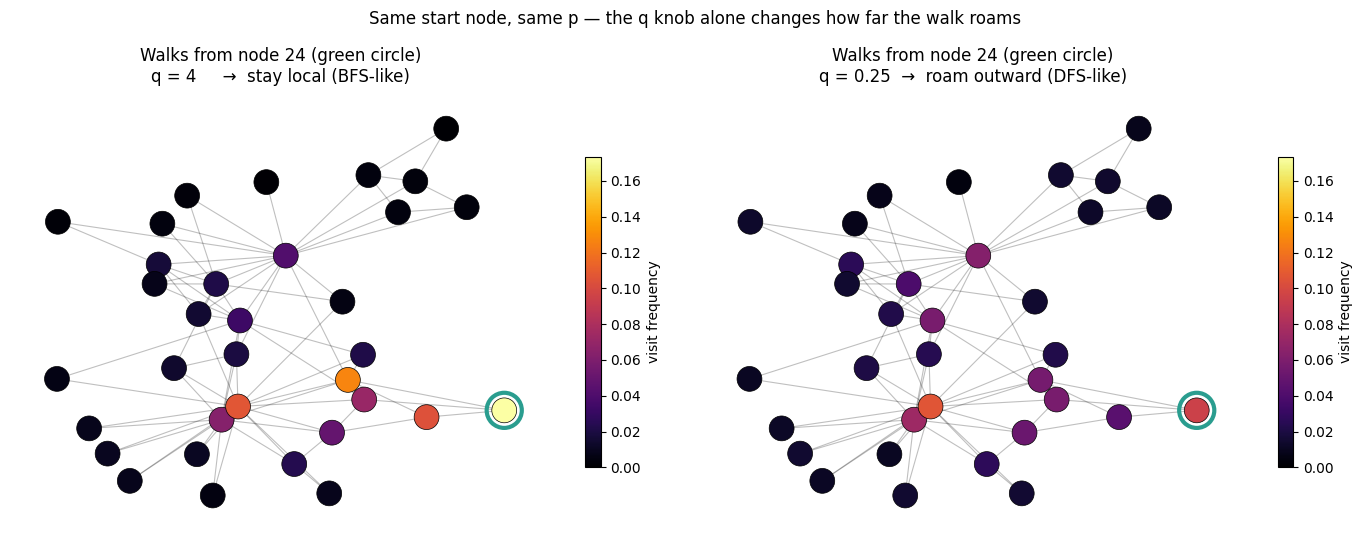

In [4]:
def walk_visit_freq(G, start, p, q, n_walks=400, walk_length=15, seed=1):
    """How often each node is visited by many biased walks from `start`."""
    rng = np.random.default_rng(seed)
    counts = np.zeros(G.number_of_nodes())
    for _ in range(n_walks):
        for v in node2vec_walk(G, start, walk_length, p, q, rng):
            counts[v] += 1
    return counts / counts.sum()


# Pick a mid-degree node that isn't sitting next to a hub: a degree-2 node
# like 9 funnels every walk through its hub neighbour on step 1, after which
# the two regimes mix the graph almost identically. Node 24 has degree 3 and
# lives in the periphery, so q actually decides where the walks go.
START = 24
regimes = [(1.0, 4.0,  "q = 4     →  stay local (BFS-like)"),
           (1.0, 0.25, "q = 0.25  →  roam outward (DFS-like)")]

# share the colour scale across both panels so absolute differences are visible
freqs = [walk_visit_freq(G, START, p, q) for p, q, _ in regimes]
vmax = max(f.max() for f in freqs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (p, q, label), freq in zip(axes, regimes, freqs):
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.8)
    nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=freq, cmap="inferno",
                                vmin=0, vmax=vmax,
                                node_size=320, edgecolors="black", linewidths=0.5)
    nx.draw_networkx_nodes(G, pos, nodelist=[START], ax=ax, node_color="none",
                           node_size=640, edgecolors="#2a9d8f", linewidths=3)
    ax.set_title(f"Walks from node {START} (green circle)\n{label}")
    ax.set_axis_off()
    plt.colorbar(nc, ax=ax, shrink=0.7, label="visit frequency")
fig.suptitle("Same start node, same p — the q knob alone changes how far the walk roams",
             fontsize=12)
plt.tight_layout()
plt.show()

## Act 1 · …from walks to vectors

The rest is exactly the DeepWalk recipe from **d1**: slide a window over each walk to
harvest `(target, context)` pairs, then train a single embedding table with skip-gram +
negative sampling. The *only* thing that changed is **which walks we feed in** — and that
is entirely controlled by `p` and `q`.

In [5]:
class NodeEmb(nn.Module):
    """One embedding table; dot product = similarity score (same as d1)."""
    def __init__(self, n, d):
        super().__init__()
        self.E = nn.Embedding(n, d)
        nn.init.normal_(self.E.weight, std=0.1)

    def forward(self, target, context, neg):
        t = self.E(target)                       # (B, d)
        c = self.E(context)                      # (B, d)
        ne = self.E(neg)                         # (B, K, d)
        pos = (t * c).sum(-1)                    # (B,)
        ng = torch.einsum("bd,bkd->bk", t, ne)   # (B, K)
        # skip-gram with negative sampling: pull context close, push negatives away
        return -(F.logsigmoid(pos).mean() + F.logsigmoid(-ng).mean())


def walks_to_pairs(walks, window=3):
    pairs = []
    for walk in walks:
        for i, tgt in enumerate(walk):
            lo, hi = max(0, i - window), min(len(walk), i + window + 1)
            for j in range(lo, hi):
                if i != j:
                    pairs.append((tgt, walk[j]))
    return np.array(pairs, dtype=np.int64)


def train_node2vec(G, p, q, dim=2, walks_per_node=20, walk_length=15,
                   window=3, epochs=250, k_neg=5, lr=0.05, seed=0):
    """Biased walks -> skip-gram -> a (N, dim) embedding array."""
    torch.manual_seed(seed)
    walks = generate_walks(G, p, q, walks_per_node, walk_length, seed=seed)
    pairs = walks_to_pairs(walks, window)
    target = torch.tensor(pairs[:, 0])
    context = torch.tensor(pairs[:, 1])
    model = NodeEmb(G.number_of_nodes(), dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    rng = np.random.default_rng(seed + 1)
    n = G.number_of_nodes()
    for _ in range(epochs):
        neg = torch.tensor(rng.integers(0, n, size=(len(pairs), k_neg)))
        loss = model(target, context, neg)
        opt.zero_grad()
        loss.backward()
        opt.step()
    return model.E.weight.detach().numpy()

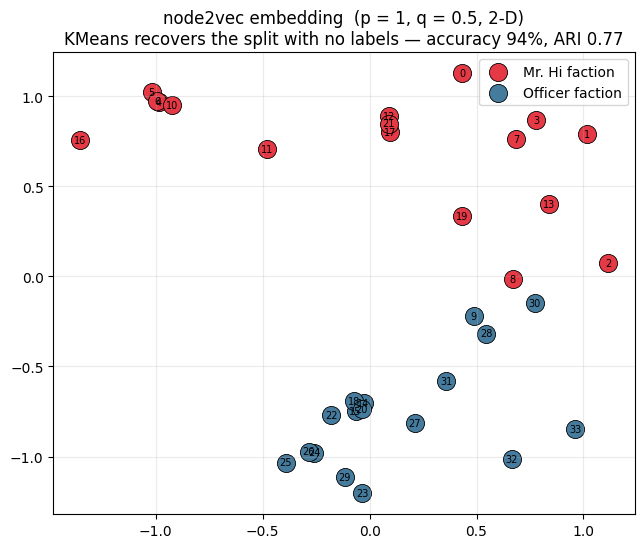

In [6]:
# homophily setting (q < 1): "similar" should mean "same faction"
emb = train_node2vec(G, p=1.0, q=0.5, dim=2, epochs=300, seed=0)

# cluster the embedding with NO access to y_true
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(emb)
acc = max((km == y_true).mean(), (km != y_true).mean())   # clusters are unlabelled
ari = adjusted_rand_score(y_true, km)

fig, ax = plt.subplots(figsize=(7.5, 6))
for f in (0, 1):
    m = y_true == f
    ax.scatter(emb[m, 0], emb[m, 1], c=FACTION_COLORS[f], s=170, edgecolors="black",
               linewidths=0.6, label=("Mr. Hi faction" if f == 0 else "Officer faction"))
for i in range(N):
    ax.annotate(str(i), (emb[i, 0], emb[i, 1]), fontsize=7, ha="center", va="center")
ax.set_title("node2vec embedding  (p = 1, q = 0.5, 2-D)\n"
             f"KMeans recovers the split with no labels — accuracy {acc:.0%}, ARI {ari:.2f}")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Act 2 · The `p` / `q` explorer — homophily vs. structural roles

We just picked `q = 0.5` and the two factions split cleanly. But that was a *choice*.
node2vec's whole selling point is that `q` lets you decide **what kind of similarity**
the embedding captures:

- **`q < 1` → homophily.** "Similar" = *in the same community*. Communities cluster.
- **`q > 1` → structural equivalence.** "Similar" = *plays the same role*. Hubs cluster
  with hubs, leaves with leaves — even across communities.

> **Switching graph for this act.** Karate club is too cleanly split for the `q` knob
> to move the embedding visibly — at every `(p, q)` you essentially get the same
> faction-coloured picture. So for Act 2 we use **Victor Hugo's *Les Misérables***
> character co-appearance graph (77 nodes, the graph the node2vec paper itself uses).
> We train at `dim = 64` and PCA-project to 2-D so both signals (community + role)
> have somewhere to live.
>
> The next cell precomputes a 3×3 grid of `(p, q)` embeddings + walk heatmaps
> (~80 s, one-off). Then a static figure (works everywhere) and an interactive slider.
> As you raise `q`, watch the **community colours** loosen and the **degree colours**
> line up.

In [7]:
import time
import networkx.algorithms.community as nxc
from sklearn.decomposition import PCA

# 1. CARICAMENTO DEL GRAFO E PULIZIA
# Carica il grafo predefinito de "I Miserabili" presente in NetworkX
LM_raw = nx.les_miserables_graph()
# Converte le etichette (i nomi testuali dei personaggi) in numeri interi da 0 a N,
# salvando il nome reale in un attributo "name". Questo facilita i calcoli matematici.
LM = nx.convert_node_labels_to_integers(LM_raw, label_attribute="name")

LM_N = LM.number_of_nodes() # Numero totale di nodi (personaggi)
LM_names = [LM.nodes[i]["name"] for i in LM.nodes()] # Lista dei nomi
LM_deg = np.array([d for _, d in LM.degree()])       # Lista dei gradi (quanti archi ha ogni nodo)

# 2. CALCOLO DELLA VERITÀ DI FONDO (GROUND TRUTH)
# Usa l'algoritmo di Louvain per trovare le "comunità" reali matematicamente.
LM_comm_sets = nxc.louvain_communities(LM, seed=0) # [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}, {12, 16, 17, 18...}]

# Crea un array vuoto e lo riempie assegnando a ciascun nodo l'ID della sua comunità (es. 0, 1, 2)
LM_comm = np.zeros(LM_N, dtype=int)
for ci, members in enumerate(LM_comm_sets):
    for n in members:
        LM_comm[n] = ci

# Calcola una disposizione spaziale statica (a molle) per eventuali visualizzazioni fisiche
LM_pos = nx.spring_layout(LM, seed=42, k=0.6, iterations=200)

# 3. SCELTA DEL NODO DI PARTENZA PER I TEST
# Seleziona un personaggio con un numero di archi medio-alto (70esimo percentile).
# Evita di scegliere Jean Valjean (il protagonista) perché essendo collegato con 
# quasi tutti, "inquinerebbe" il test rendendo invisibile l'effetto del parametro q.
mid_idx = np.argsort(LM_deg)[int(0.7 * LM_N)]      
START_LM = int(mid_idx)

print(f"Les Mis: {LM_N} nodes, {LM.number_of_edges()} edges,",
      f"{len(LM_comm_sets)} Louvain communities · slider starts at",
      f"#{START_LM} ('{LM_names[START_LM]}', deg {LM_deg[START_LM]})")

# 4. ADDESTRAMENTO MASSIVO (LA GRIGLIA)
# Definisce i 3 valori di p e i 3 valori di q da testare.
P_GRID = [0.25, 1.0, 4.0]
Q_GRID = [0.25, 1.0, 4.0]

emb_cache, heat_cache = {}, {}
t0 = time.time()

# Avvia 9 addestramenti separati e salva i risultati nei dizionari (cache)
for p in P_GRID:
    for q in Q_GRID:
        # Addestra Node2Vec calcolando per ogni nodo un vettore (embedding) di 64 dimensioni.
        emb_cache[(p, q)] = train_node2vec(LM, p=p, q=q, dim=64,
                                           walks_per_node=15, walk_length=15,
                                           window=5, epochs=120, seed=0)
        # Registra con quale frequenza il camminatore visita i vari nodi
        heat_cache[(p, q)] = walk_visit_freq(LM, START_LM, p=p, q=q)
    print(f"  p = {p}  done   (cumulative {time.time() - t0:.0f} s)")

print(f"grid ready: {len(emb_cache)} embeddings · total {time.time() - t0:.0f} s")

Les Mis: 77 nodes, 254 edges, 6 Louvain communities · slider starts at #71 ('Montparnasse', deg 9)
  p = 0.25  done   (cumulative 176 s)
  p = 1.0  done   (cumulative 358 s)


KeyboardInterrupt: 

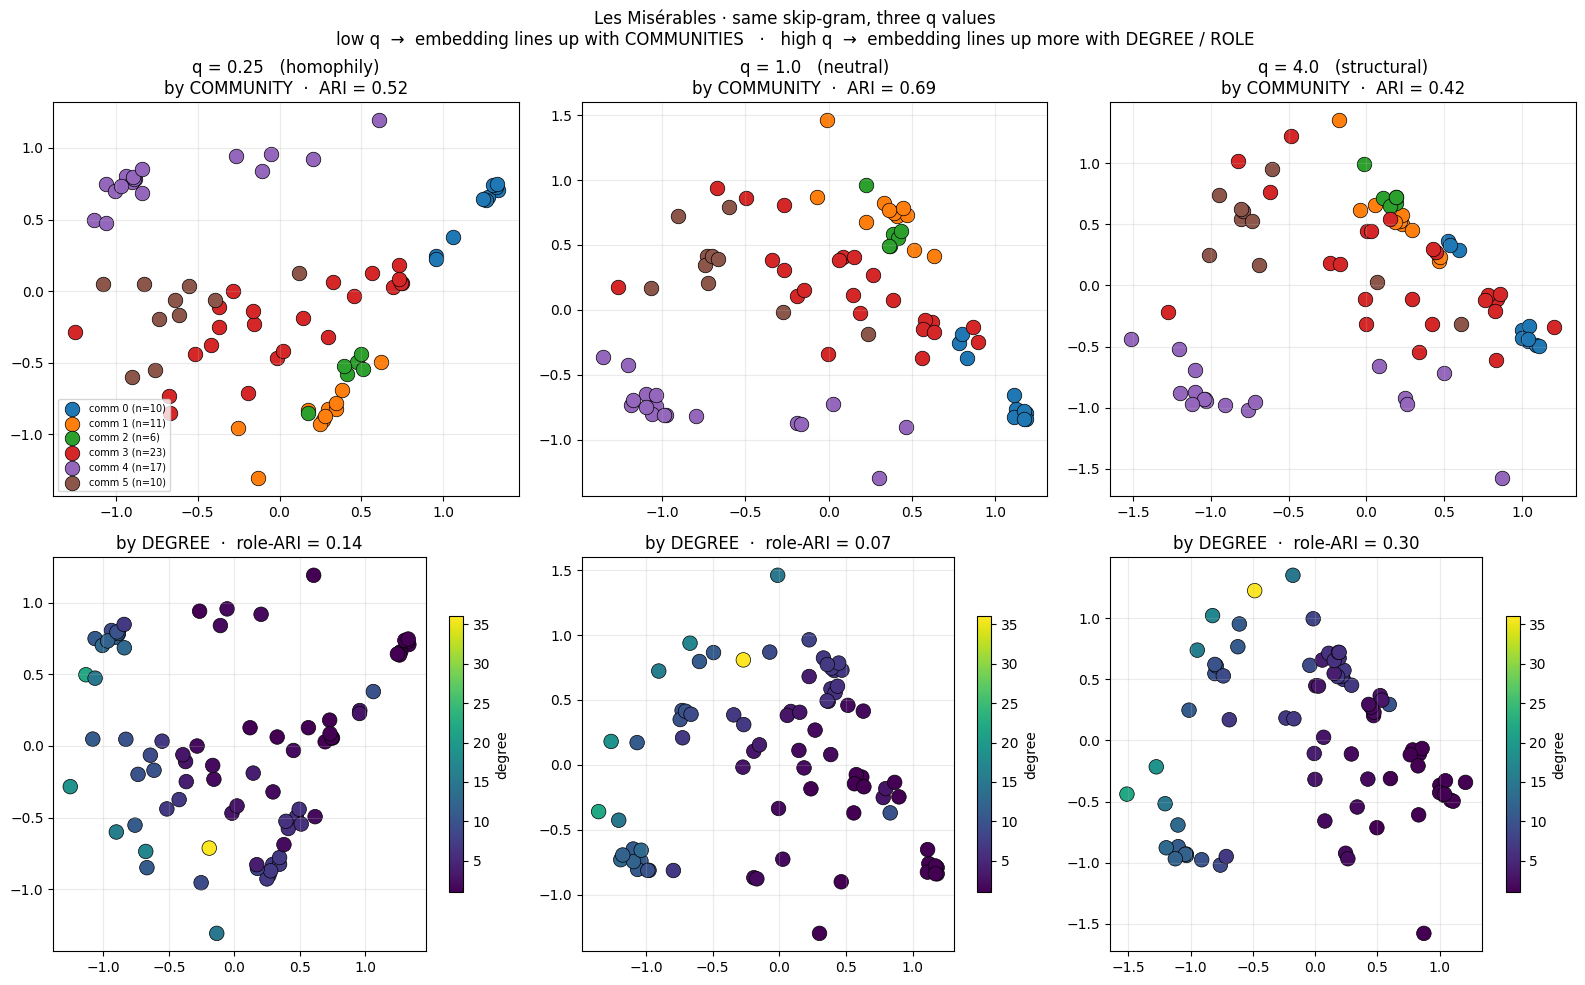

In [ ]:
# Imposta i 3 valori di 'q' da analizzare e crea una figura con 2 righe e 3 colonne.
Q_VALUES = [0.25, 1.0, 4.0]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Crea una "verità di fondo" per i RUOLI dividendoli per grado (popolarità).
# I nodi vengono divisi in 4 categorie a seconda se sono poco o molto connessi.
role = np.digitize(LM_deg, np.quantile(LM_deg, [0.25, 0.5, 0.75]))

# Cicla sui 3 valori di Q per riempire le colonne del grafico
for col, q in enumerate(Q_VALUES):
    
    # Estrae l'embedding addestrato e usa la PCA per portarlo da 64D a 2D (coordinate X e Y)
    E = emb_cache[(1.0, q)]
    P2 = PCA(n_components=2).fit_transform(E)
    
    # 1. VALUTAZIONE MATEMATICA: Applica un algoritmo di clustering (KMeans) sulle coordinate
    # e misura (tramite ARI) quanto bene i punti raggruppati dall'IA corrispondono
    # alle COMUNITÀ reali e ai RUOLI reali.
    ari_comm = adjusted_rand_score(LM_comm,
                  KMeans(n_clusters=len(LM_comm_sets), n_init=10, random_state=0).fit_predict(E))
    ari_role = adjusted_rand_score(role,
                  KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(E))
    
    # Dà un nome al comportamento: q basso = Esplora vicino (Omofilia), q alto = Esplora lontano (Struttura)
    regime = "homophily" if q < 1 else ("neutral" if q == 1 else "structural")

    # 2. DISEGNO RIGA SUPERIORE (Colore = Comunità)
    cmap_c = plt.get_cmap("tab10")
    for ci in range(len(LM_comm_sets)):
        m = LM_comm == ci # Maschera logica per selezionare i nodi della comunità 'ci'
        # Disegna i punti assegnando a ogni comunità un colore diverso
        axes[0, col].scatter(P2[m, 0], P2[m, 1], c=[cmap_c(ci)], s=110,
                             edgecolors="black", linewidths=0.5,
                             label=f"comm {ci} (n={m.sum()})")
    
    # Nota come, col 'q' basso, il punteggio ARI sia altissimo (punti dello stesso colore vicini)
    axes[0, col].set_title(f"q = {q}   ({regime})\nby COMMUNITY  ·  ARI = {ari_comm:.2f}")
    axes[0, col].grid(alpha=0.25)

    # 3. DISEGNO RIGA INFERIORE (Colore = Grado/Ruolo)
    # Qui il colore del punto non dipende più dalla fazione, ma da quanti amici ha (il grado).
    # Giallo = Popolare (Hub), Viola = Isolato.
    sc = axes[1, col].scatter(P2[:, 0], P2[:, 1], c=LM_deg, cmap="viridis", s=110,
                              edgecolors="black", linewidths=0.5)
    
    # Nota come, col 'q' alto, il punteggio ARI per il ruolo aumenti: l'IA posiziona i VIP (gialli)
    # tutti nello stesso angolo, anche se non si conoscono tra loro!
    axes[1, col].set_title(f"by DEGREE  ·  role-ARI = {ari_role:.2f}")
    axes[1, col].grid(alpha=0.25)
    plt.colorbar(sc, ax=axes[1, col], shrink=0.7, label="degree")

# Rifiniture grafiche finali
axes[0, 0].legend(fontsize=7, loc="best")
fig.suptitle("Les Misérables · same skip-gram, three q values\n"
             "low q  →  embedding lines up with COMMUNITIES   ·   "
             "high q  →  embedding lines up more with DEGREE / ROLE",
             fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# interactive version — drag the sliders to explore (p, q) on Les Misérables
def explore(p, q):
    E = emb_cache[(p, q)]
    P2 = PCA(n_components=2).fit_transform(E)
    freq = heat_cache[(p, q)]
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))

    # (1) embedding coloured by community  (homophily evidence)
    cmap_c = plt.get_cmap("tab10")
    for ci in range(len(LM_comm_sets)):
        m = LM_comm == ci
        ax[0].scatter(P2[m, 0], P2[m, 1], c=[cmap_c(ci)], s=80,
                      edgecolors="black", linewidths=0.4,
                      label=f"comm {ci}")
    ax[0].set_title("embedding — coloured by COMMUNITY\n(tight clusters = homophily captured)")
    ax[0].legend(fontsize=7, loc="best")

    # (2) embedding coloured by degree  (structural-role evidence)
    sc = ax[1].scatter(P2[:, 0], P2[:, 1], c=LM_deg, cmap="viridis", s=80,
                       edgecolors="black", linewidths=0.4)
    ax[1].set_title("embedding — coloured by DEGREE\n(clean gradient = structural role captured)")
    plt.colorbar(sc, ax=ax[1], shrink=0.7, label="degree")

    # (3) walk heatmap from a chosen start node
    nx.draw_networkx_edges(LM, LM_pos, ax=ax[2], alpha=0.18, width=0.5)
    nx.draw_networkx_nodes(LM, LM_pos, ax=ax[2], node_color=freq, cmap="inferno",
                           node_size=70, edgecolors="black", linewidths=0.3)
    nx.draw_networkx_nodes(LM, LM_pos, nodelist=[START_LM], ax=ax[2], node_color="none",
                           node_size=240, edgecolors="#2a9d8f", linewidths=2.5)
    ax[2].set_title(f"where walks from '{LM_names[START_LM]}' go (deg {LM_deg[START_LM]})")
    ax[2].set_axis_off()
    for a in ax[:2]:
        a.grid(alpha=0.25)
    fig.suptitle(f"node2vec on Les Misérables    ·    p = {p}    q = {q}", fontsize=13)
    plt.tight_layout()
    plt.show()


interact(explore,
         p=widgets.SelectionSlider(options=P_GRID, value=1.0, description="p (return)"),
         q=widgets.SelectionSlider(options=Q_GRID, value=1.0, description="q (in-out)"));

interactive(children=(SelectionSlider(description='p (return)', index=1, options=(0.25, 1.0, 4.0), value=1.0),…

## Act 3 · Link prediction — vectors that predict edges

An embedding should be *useful*, not just decorative. The classic test:
**hide some edges, then ask the embedding to find them again.**

1. Remove 20 % of edges (keeping the graph connected). These become the *positive* test set.
2. Train node2vec on the damaged graph — it never sees the hidden edges.
3. Turn a *pair* of nodes into a feature: the **Hadamard product** `e_u ⊙ e_v`
   (the operator recommended in the node2vec paper).
4. Train a logistic regression: real edges vs. random non-edges.
5. Score every missing pair — do the truly-hidden edges float to the top?

In [ ]:
rng = np.random.default_rng(0)
edges = list(G.edges())
rng.shuffle(edges)
n_remove = int(0.20 * len(edges))

G_train = G.copy()
removed = []
for u, v in edges:
    if len(removed) >= n_remove:
        break
    G_train.remove_edge(u, v)
    if nx.is_connected(G_train):          # only hide an edge if the graph stays in one piece
        removed.append((u, v))
    else:
        G_train.add_edge(u, v)

print(f"hid {len(removed)} of {len(edges)} edges · still connected: {nx.is_connected(G_train)}")

# candidate non-edges = pairs that are NOT edges in the original graph
all_non_edges = [(u, v) for u, v in nx.non_edges(G)]
rng.shuffle(all_non_edges)

hid 15 of 78 edges · still connected: True


In [ ]:
emb_lp = train_node2vec(G_train, p=1.0, q=0.5, dim=16, epochs=300, seed=0)

def pair_feats(pairs):
    """Hadamard product of the two node vectors."""
    return np.array([emb_lp[u] * emb_lp[v] for u, v in pairs])

pos_train = list(G_train.edges())                    # surviving edges  -> label 1
neg_train = all_non_edges[:len(pos_train)]           # random non-edges -> label 0
pos_test = removed                                   # hidden edges     -> label 1
neg_test = all_non_edges[len(pos_train):len(pos_train) + len(pos_test)]

X_train = np.vstack([pair_feats(pos_train), pair_feats(neg_train)])
y_train = np.r_[np.ones(len(pos_train)), np.zeros(len(neg_train))]
X_test = np.vstack([pair_feats(pos_test), pair_feats(neg_test)])
y_test = np.r_[np.ones(len(pos_test)), np.zeros(len(neg_test))]

clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
scores = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)
print(f"link-prediction AUC on the hidden edges: {roc_auc:.3f}   (0.5 = random guessing)")

link-prediction AUC on the hidden edges: 0.636   (0.5 = random guessing)


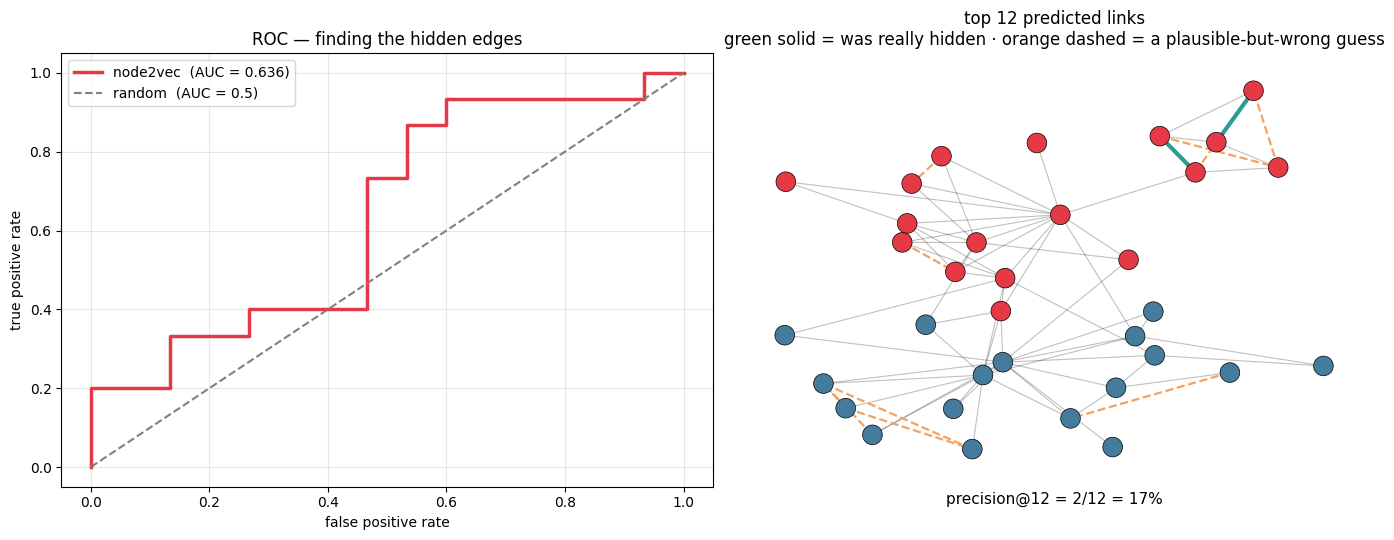

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

ax[0].plot(fpr, tpr, lw=2.5, color="#e63946", label=f"node2vec  (AUC = {roc_auc:.3f})")
ax[0].plot([0, 1], [0, 1], "--", color="gray", label="random  (AUC = 0.5)")
ax[0].set_xlabel("false positive rate")
ax[0].set_ylabel("true positive rate")
ax[0].set_title("ROC — finding the hidden edges")
ax[0].legend()
ax[0].grid(alpha=0.3)

# rank every missing pair of the training graph; show the strongest predictions
missing = [(u, v) for u, v in nx.non_edges(G_train)]
missing_scores = clf.predict_proba(pair_feats(missing))[:, 1]
order = np.argsort(missing_scores)[::-1]
top_k = 12
removed_set = {frozenset(e) for e in removed}

nx.draw_networkx_edges(G_train, pos, ax=ax[1], alpha=0.25, width=0.8)
nx.draw_networkx_nodes(G_train, pos, ax=ax[1], node_color=node_color, node_size=200,
                       edgecolors="black", linewidths=0.5)
hit = 0
for idx in order[:top_k]:
    u, v = missing[idx]
    is_true = frozenset((u, v)) in removed_set
    hit += is_true
    nx.draw_networkx_edges(G_train, pos, edgelist=[(u, v)], ax=ax[1],
                           edge_color=("#2a9d8f" if is_true else "#f4a261"),
                           width=(3.0 if is_true else 1.6),
                           style=("solid" if is_true else "dashed"))
ax[1].set_title(f"top {top_k} predicted links\n"
                "green solid = was really hidden · orange dashed = a plausible-but-wrong guess")
ax[1].set_axis_off()
ax[1].text(0.5, -0.04, f"precision@{top_k} = {hit}/{top_k} = {hit / top_k:.0%}",
           transform=ax[1].transAxes, ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## Act 4 · The ceiling of shallow embeddings — enter the GCN

Everything so far shares one design: **one free vector per node**, looked up from a table.
That table has real limits:

- **No features.** If nodes carry attributes (a paper's words, a user's age), node2vec
  cannot use them — it only sees wiring.
- **Transductive.** The table has a column for *these* nodes only. A new member joins
  the club ⇒ retrain from scratch.
- **No parameter sharing.** Every node's vector is learned in isolation.

A **Graph Convolutional Network** flips this. Instead of *storing* a vector per node it
learns *functions* that **mix each node's features with its neighbours'** — message
passing — using the same small set of weights for the whole graph. Below we give the GCN
only **4 labelled nodes** (2 per faction) and let message passing carry those labels
across the other 30.

In [ ]:
# ==============================================================================
# BLOCCO 1: PREPARAZIONE DATI PER LA GNN (GRAPH NEURAL NETWORK)
# ==============================================================================
print("torch-geometric", torch_geometric.__version__)

# 1. Creazione degli 'edge_index' (Il formato standard per i grafi in PyTorch Geometric)
# GNNs necessitano della lista di TUTTI i collegamenti (archi).
# 'e' è un tensore di forma [2, Numero_Archi] dove la prima riga sono i nodi di partenza e la seconda i nodi di arrivo.
e = torch.tensor(list(G.edges()), dtype=torch.long).t()

# I grafi sociali sono "non orientati" (se A è amico di B, B è amico di A). 
# Quindi concateniamo gli archi normali con gli archi capovolti (e.flip) per assicurarci
# che l'informazione viaggi in entrambe le direzioni durante il Message Passing.
edge_index = torch.cat([e, e.flip(0)], dim=1)

# 2. Inizializzazione delle caratteristiche (Features) dei nodi
# In molti problemi reali (es. molecole), ogni nodo ha delle proprietà chimiche iniziali.
# Nel Karate Club, i nodi sono solo persone anonime. 
# Quindi diamo a ogni nodo la "Matrice Identità" (I): l'unica cosa che il nodo sa all'inizio 
# è il suo identificativo univoco.
x = torch.eye(N)                                  
y = torch.tensor(y_true, dtype=torch.long)

# 3. Il trucco del "Semi-Supervised Learning" (Apprendimento Semi-Supervisionato)
# Vogliamo vedere se l'IA riesce a indovinare a quale fazione appartengono tutti i 34 membri
# avendole svelato le etichette di SOLO 4 PERSONE (i primi 2 di Mr. Hi e i primi 2 dell'Officer).
train_mask = torch.zeros(N, dtype=torch.bool)
for f in (0, 1): # Per ognuna delle due fazioni
    for idx in np.where(y_true == f)[0][:2]: # Prendi i primi 2 nodi trovati
        train_mask[idx] = True # Etichettali come "dati di addestramento"

test_mask = ~train_mask # I restanti 30 nodi saranno il banco di prova (Test)
print("labelled nodes:", torch.where(train_mask)[0].tolist())

torch-geometric 2.7.0
labelled nodes: [0, 1, 9, 14]


In [ ]:

# ==============================================================================
# BLOCCO 2: DEFINIZIONE E ADDESTRAMENTO DELLA GRAPH CONVOLUTIONAL NETWORK (GCN)
# ==============================================================================

# Definiamo l'architettura della rete neurale
class GCN(torch_nn.Module):
    def __init__(self, in_dim, hidden=8):
        super().__init__()
        # Primo strato (Layer) GCN: prende i dati di input (le identità) e li comprime a 'hidden' (8) dimensioni.
        self.conv1 = GCNConv(in_dim, hidden)
        
        # Secondo strato GCN: comprime le 8 dimensioni in sole 2 dimensioni.
        # È stato scelto 2D di proposito affinché tu possa stampare a schermo le coordinate (X, Y) 
        # e vedere fisicamente come l'IA sposta i nodi.
        self.conv2 = GCNConv(hidden, 2)       
        
        # Uno strato lineare classico che trasforma le coordinate 2D in 2 probabilità (fazione A o fazione B).
        self.head = torch_nn.Linear(2, 2)           

    def forward(self, x, edge_index):
        # Passo in avanti: applica la convoluzione e usa 'tanh' per limitare i numeri tra -1 e 1
        h = torch.tanh(self.conv1(x, edge_index))
        # Secondo strato: questo 'h' in uscita sarà il nostro vettore (embedding) 2D finale
        h = torch.tanh(self.conv2(h, edge_index))   
        
        # Ritorna sia le probabilità finali (per calcolare l'errore), sia le coordinate 'h' (per il grafico).
        return self.head(h), h

torch.manual_seed(1)
gcn = GCN(N)
# L'ottimizzatore Adam aggiusterà i pesi dei layer GCN per ridurre l'errore.
opt = torch.optim.Adam(gcn.parameters(), lr=0.02, weight_decay=5e-4)
loss_fn = torch_nn.CrossEntropyLoss()

# Salviamo la posizione dei nodi (le coordinate 2D) a epoche specifiche per fare un'animazione.
SNAP_EPOCHS = [0, 10, 40, 200]
snaps = {}

# Ciclo di addestramento (200 passaggi)
for epoch in range(SNAP_EPOCHS[-1] + 1):
    gcn.train()
    # 1. Chiedi alla GCN di fare le predizioni. Il "Message Passing" avviene ORA: 
    # i nodi si passano le informazioni lungo gli archi (edge_index).
    out, h = gcn(x, edge_index)
    
    if epoch in SNAP_EPOCHS:
        snaps[epoch] = h.detach().numpy() # Salva la fotografia delle coordinate spaziali in quel momento
        
    # 2. CALCOLO DELL'ERRORE (LOSS). Questo è il passaggio magico:
    # La GCN viene punita SOLO SE sbaglia a classificare i 4 NODI ETICHETTATI (train_mask).
    # Non ha idea di che colore debbano avere gli altri 30 nodi!
    loss = loss_fn(out[train_mask], y[train_mask])  
    
    opt.zero_grad()
    loss.backward()
    opt.step() # Aggiorna i pesi della rete

# Valutazione finale
gcn.eval()
out, _ = gcn(x, edge_index)
pred = out.argmax(1)
# Verifichiamo quante volte la rete ha indovinato sui 30 nodi NASCOSTI
gcn_acc = (pred[test_mask] == y[test_mask]).float().mean().item()
n_params = sum(param.numel() for param in gcn.parameters())
print(f"GCN accuracy on the 30 unlabelled nodes: {gcn_acc:.0%}   ({n_params} parameters total)")


GCN accuracy on the 30 unlabelled nodes: 97%   (304 parameters total)


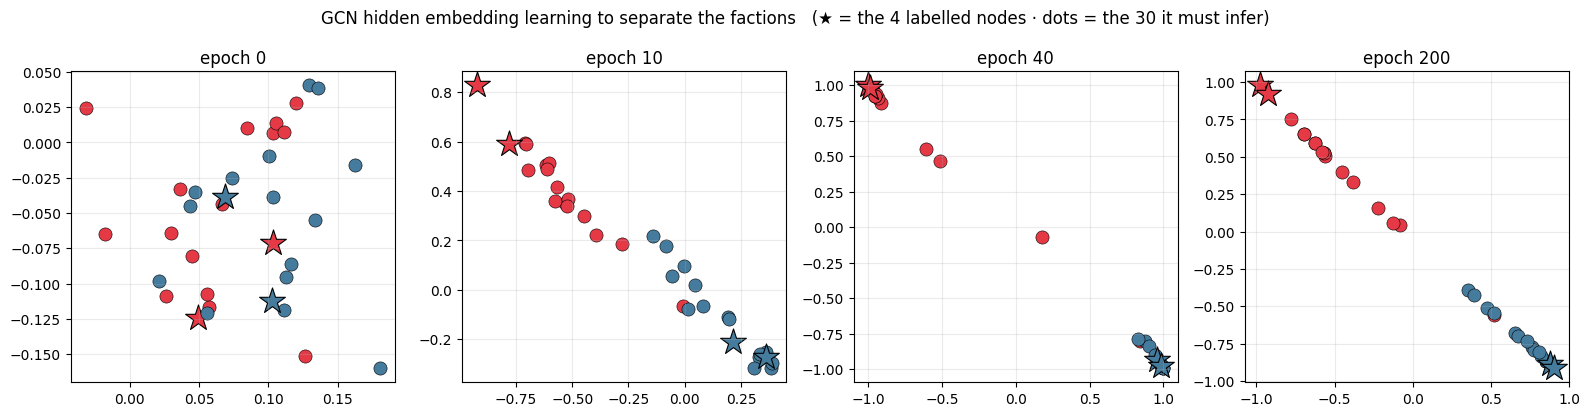

In [ ]:

# ==============================================================================
# BLOCCO 3: VISUALIZZAZIONE DEL "MESSAGE PASSING" IN AZIONE
# ==============================================================================
tm = train_mask.numpy()
fig, axes = plt.subplots(1, len(SNAP_EPOCHS), figsize=(4 * len(SNAP_EPOCHS), 4.2))

# Creiamo 4 riquadri, uno per ogni epoca che abbiamo salvato (0, 10, 40, 200)
for ax, ep in zip(axes, SNAP_EPOCHS):
    H = snaps[ep] # Prendi le coordinate (X,Y) calcolate dalla GCN in quell'epoca
    
    for f in (0, 1): # Per ogni fazione (0=Mr.Hi, 1=Officer)
        # Nodi non etichettati (punti piccoli)
        unlabelled = (y_true == f) & ~tm
        # I famosi 4 nodi etichettati (stelle giganti)
        labelled = (y_true == f) & tm
        
        # Disegna i punti sulla griglia 2D
        ax.scatter(H[unlabelled, 0], H[unlabelled, 1], c=FACTION_COLORS[f], s=90,
                   edgecolors="black", linewidths=0.4)
        ax.scatter(H[labelled, 0], H[labelled, 1], c=FACTION_COLORS[f], s=380,
                   marker="*", edgecolors="black", linewidths=0.8)
                   
    ax.set_title(f"epoch {ep}")
    ax.grid(alpha=0.25)
    
# SPIEGAZIONE DEL RISULTATO VISIVO:
# All'Epoca 0, i nodi sono mescolati a caso.
# Man mano che l'addestramento procede (Epoca 10, 40, 200), le due grandi Stelle Rosse (i capi)
# si allontanano dalle due Stelle Blu. 
# La magia del Message Passing è che, trascinandosi dietro i loro amici, i 4 nodi etichettati
# si "tirano dietro" tutto il resto della loro fazione, separando perfettamente lo spazio 
# senza che nessuno avesse mai detto all'IA quali fossero i colori dei 30 pallini più piccoli!
fig.suptitle("GCN hidden embedding learning to separate the factions   "
             "(★ = the 4 labelled nodes · dots = the 30 it must infer)", fontsize=12)
plt.tight_layout()
plt.show()

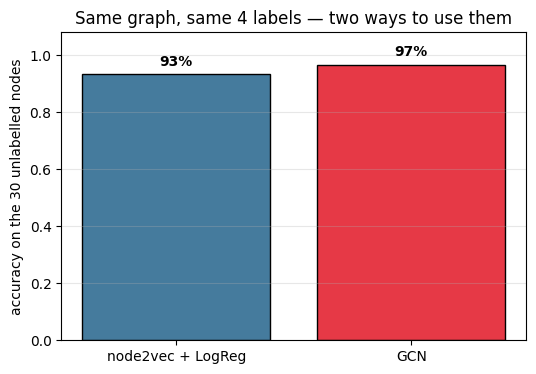

On a 34-node graph both usually do well — the point is not the score, it is *how*
they get there: node2vec needs the whole graph + a separate classifier; the GCN
propagates 4 labels through message passing with one shared set of weights.


In [ ]:
# ==============================================================================
# BLOCCO 4: LO SCONTRO FINALE (NODE2VEC vs GCN)
# ==============================================================================

# Generiamo i vettori con Node2Vec per fare un paragone (come fatto nell'Atto 1)
emb_n2v = train_node2vec(G, p=1.0, q=0.5, dim=16, epochs=300, seed=0)

# A differenza della GCN che fa la classificazione internamente, Node2Vec ha bisogno
# di un modello esterno (es. una Regressione Logistica) per fare delle predizioni.
# Addestriamo la Regressione Logistica SOLO sui 4 vettori dei nodi etichettati.
lr_clf = LogisticRegression(max_iter=1000).fit(emb_n2v[tm], y_true[tm])
# E la facciamo scommettere sui restanti 30 nodi
n2v_acc = lr_clf.score(emb_n2v[test_mask.numpy()], y_true[test_mask.numpy()])

# Creiamo un istogramma (Bar Chart) per confrontare la precisione dei due metodi
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["node2vec + LogReg", "GCN"], [n2v_acc, gcn_acc],
              color=["#457b9d", "#e63946"], edgecolor="black")
ax.set_ylim(0, 1.08)
ax.set_ylabel("accuracy on the 30 unlabelled nodes")
ax.set_title("Same graph, same 4 labels — two ways to use them")

# Scrive il numero della percentuale sopra le sbarre
for b, val in zip(bars, [n2v_acc, gcn_acc]):
    ax.text(b.get_x() + b.get_width() / 2, val + 0.03, f"{val:.0%}",
            ha="center", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.show()

# CONCLUSIONE DIDATTICA:
# Non guardare solo chi "vince" (su 34 nodi è facile vincere per entrambi).
# Il punto del notebook è capire LA DIFFERENZA ARCHITETTONICA:
# - Node2Vec: Impara i vettori "alla cieca" passeggiando sul grafo, salva le posizioni in 
#             una tabella statica, e POI devi appiccicarci un classificatore esterno.
# - GCN: È un sistema "end-to-end". I vettori vengono calcolati e la classificazione viene
#        fatta contemporaneamente, sfruttando l'architettura dinamica (le sinapsi) del grafo
#        durante il passaggio di messaggi (Message Passing).
print("On a 34-node graph both usually do well — the point is not the score, it is *how*",
      "they get there: node2vec needs the whole graph + a separate classifier; the GCN",
      "propagates 4 labels through message passing with one shared set of weights.", sep="\n")

## Where this leaves us

|                          | DeepWalk / node2vec (shallow)            | GCN (deep)                                  |
|--------------------------|------------------------------------------|---------------------------------------------|
| what is learned          | one vector per node, from a lookup table | weight matrices shared across all nodes     |
| uses node features?      | no — wiring only                         | yes — features mixed with neighbours        |
| a new node appears       | retrain                                  | just run the function (if it has features)  |
| the `q` knob             | homophily ⇄ structural roles             | (decided by architecture / task)            |
| shines when              | plain graphs, no attributes              | attributed graphs, need to generalise       |

node2vec carried Acts 1–3 and it is genuinely strong on plain graphs. But the moment
nodes carry information, or the graph keeps growing, you want a model that learns a
*function of the neighbourhood* instead of a frozen table. That function is **message
passing** — and message passing is the whole of **Session 10**.

### Things to try in class
- Push `q` to the extremes in the **Act 2** explorer — where does node `0` (a hub) land?
- In **Act 4**, label two nodes from the *same* faction. Does the GCN still recover the split?
- Bump the GCN's `hidden` size, or add a third `GCNConv`. Better, or overfitting on 4 labels?
- Hide 40 % of edges in **Act 3** and watch the AUC fall.

*Companion to `G2_graph-02-nodeemb.pptx`. Builds on demo `d1` (DeepWalk from scratch)
and `d2` (the NetworkX playground).*